# Notebook 04 — SHAP Explainability

Uses SHAP to produce global importance, beeswarm, waterfall,
dependence and interaction plots for the best model.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import shap, joblib
from src.preprocessing import load_preprocessed
from src.model_utils import load_model

In [2]:
X_train, X_test, y_train, y_test, scaler = load_preprocessed('../outputs')
best_model = load_model('best_model', model_dir='../models')
print(f'Model: {type(best_model).__name__}  |  Test shape: {X_test.shape}')

Loaded  X_train=(17534, 14)  X_test=(2474, 14)
Loaded ../models/best_model.pkl
Model: GradientBoostingClassifier  |  Test shape: (2474, 14)


In [3]:
# Create explainer
mtype = type(best_model).__name__
if mtype in ('RandomForestClassifier', 'GradientBoostingClassifier', 'XGBClassifier'):
    explainer = shap.TreeExplainer(best_model)
    print(f'TreeExplainer for {mtype}')
else:
    bg = shap.sample(X_train, 100)
    explainer = shap.KernelExplainer(best_model.predict_proba, bg)
    print(f'KernelExplainer for {mtype}')

sample = X_test.iloc[:500]
sv = explainer.shap_values(sample)
sv_pos = sv[1] if isinstance(sv, list) else sv
print(f'SHAP values shape: {sv_pos.shape}')

TreeExplainer for GradientBoostingClassifier
SHAP values shape: (500, 14)


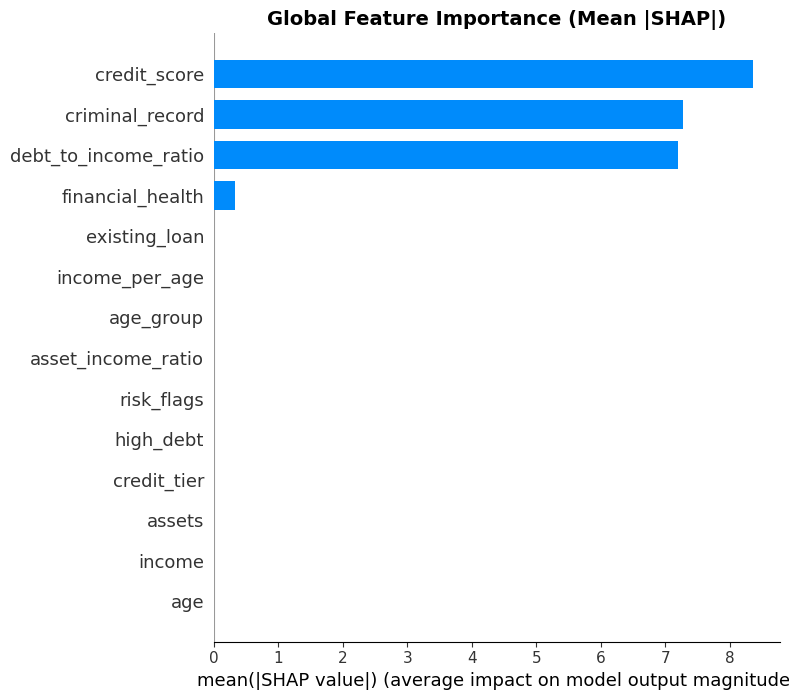

In [4]:
# Global bar
plt.figure(figsize=(12, 8))
shap.summary_plot(sv_pos, sample, plot_type='bar', show=False)
plt.title('Global Feature Importance (Mean |SHAP|)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('../outputs/shap_global_importance.png', dpi=150, bbox_inches='tight'); plt.show()

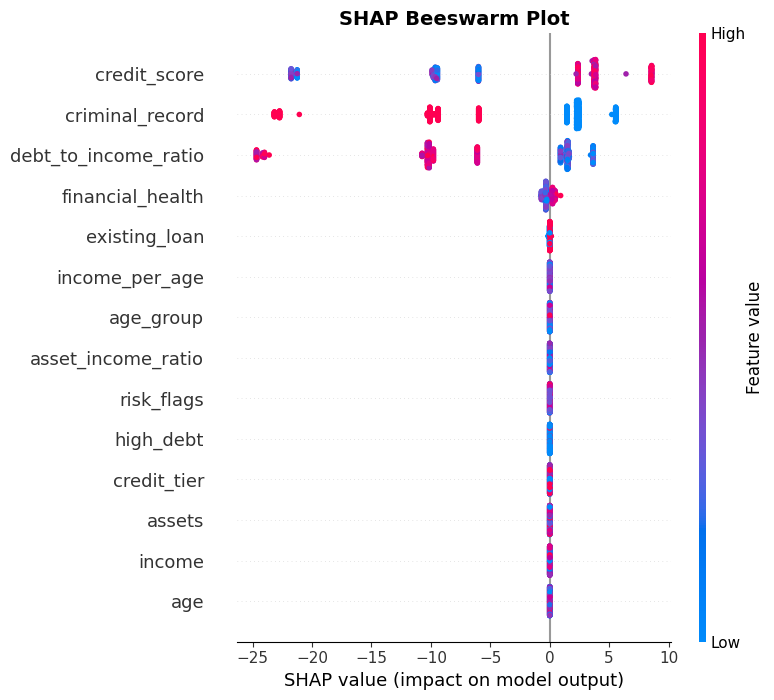

In [5]:
# Beeswarm
plt.figure(figsize=(12, 8))
shap.summary_plot(sv_pos, sample, show=False)
plt.title('SHAP Beeswarm Plot', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('../outputs/shap_beeswarm.png', dpi=150, bbox_inches='tight'); plt.show()

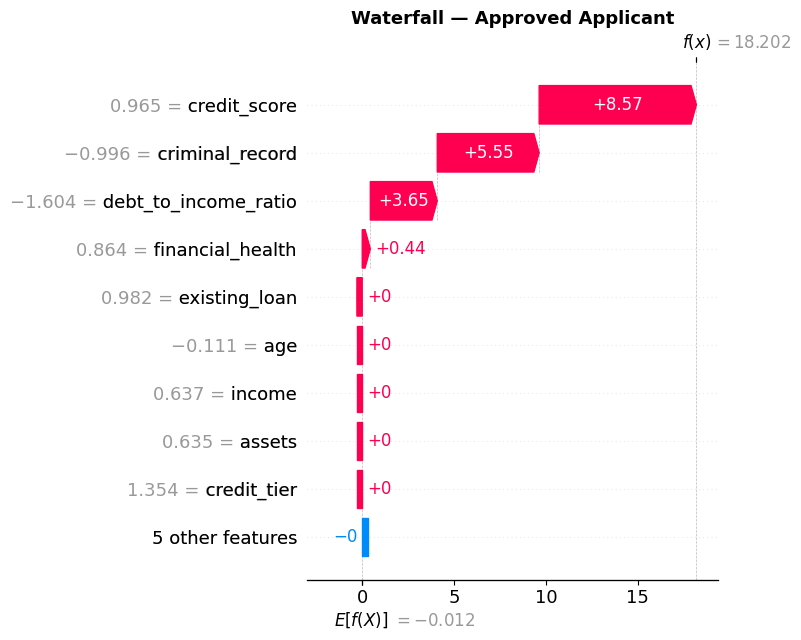

In [6]:
# Waterfall — approved
y_pred = best_model.predict(sample)
approved_idx = np.where(y_pred == 1)[0]
rejected_idx = np.where(y_pred == 0)[0]

ev = explainer.expected_value
if isinstance(ev, (list, np.ndarray)) and np.asarray(ev).size > 1:
    base = float(np.asarray(ev)[1])
else:
    base = float(np.asarray(ev).item())

if len(approved_idx):
    i = approved_idx[0]
    exp = shap.Explanation(values=sv_pos[i], base_values=base,
                           data=sample.iloc[i].values, feature_names=sample.columns.tolist())
    plt.figure(figsize=(12, 7))
    shap.plots.waterfall(exp, show=False)
    plt.title('Waterfall — Approved Applicant', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('../outputs/shap_waterfall_approved.png', dpi=150, bbox_inches='tight'); plt.show()

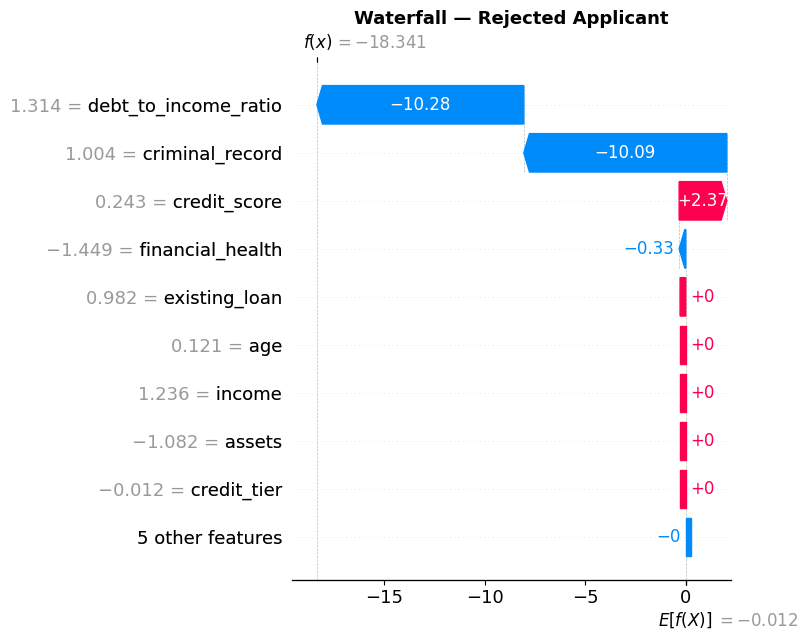

In [7]:
# Waterfall — rejected
if len(rejected_idx):
    i = rejected_idx[0]
    exp = shap.Explanation(values=sv_pos[i], base_values=base,
                           data=sample.iloc[i].values, feature_names=sample.columns.tolist())
    plt.figure(figsize=(12, 7))
    shap.plots.waterfall(exp, show=False)
    plt.title('Waterfall — Rejected Applicant', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('../outputs/shap_waterfall_rejected.png', dpi=150, bbox_inches='tight'); plt.show()

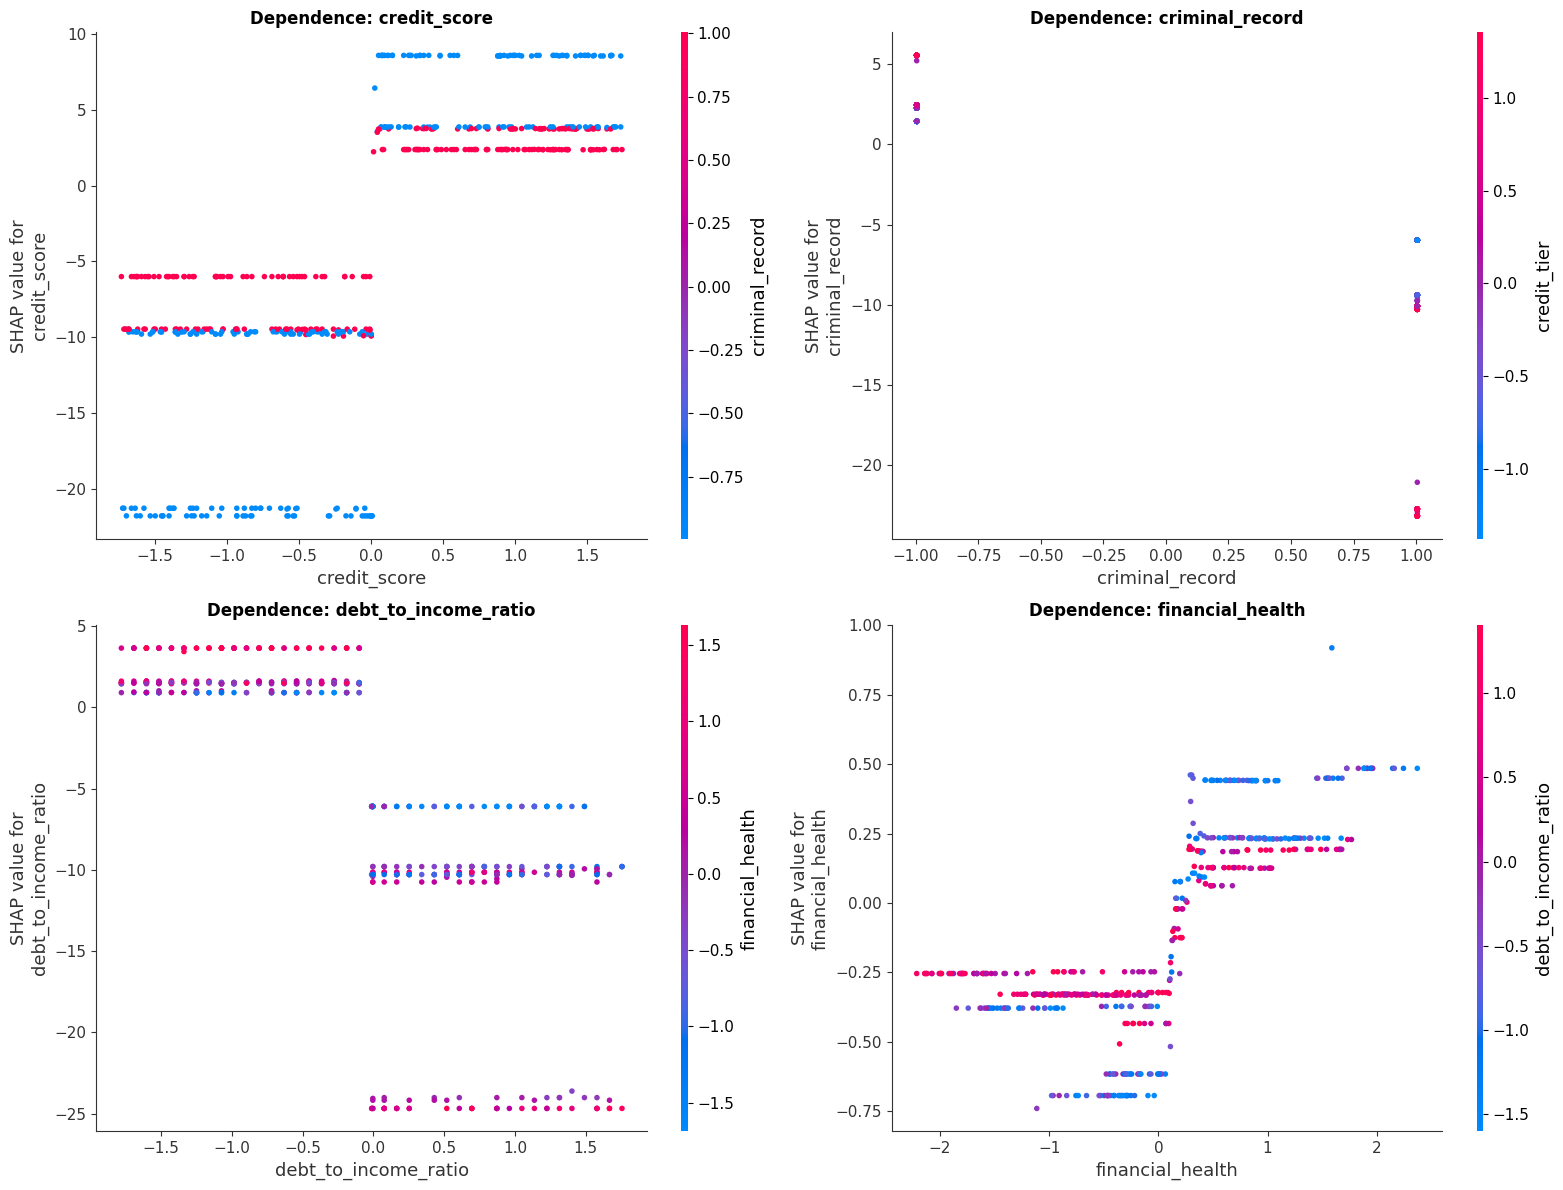

In [8]:
# Dependence plots — top 4 features
top4 = sample.columns[np.argsort(np.abs(sv_pos).mean(0))[-4:][::-1]]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, feat in zip(axes.ravel(), top4):
    shap.dependence_plot(feat, sv_pos, sample, ax=ax, show=False)
    ax.set_title(f'Dependence: {feat}', fontweight='bold')
plt.tight_layout(); plt.savefig('../outputs/shap_dependence.png', dpi=150, bbox_inches='tight'); plt.show()

In [9]:
# Save importance CSV
imp_df = pd.DataFrame({
    'Feature': sample.columns,
    'Mean_Abs_SHAP': np.abs(sv_pos).mean(0)
}).sort_values('Mean_Abs_SHAP', ascending=False)
imp_df.to_csv('../outputs/shap_importance.csv', index=False)
print(imp_df.round(4).to_string(index=False))
print('\nSHAP analysis complete.')

             Feature  Mean_Abs_SHAP
        credit_score         8.3576
     criminal_record         7.2761
debt_to_income_ratio         7.1960
    financial_health         0.3279
       existing_loan         0.0076
                 age         0.0000
              income         0.0000
              assets         0.0000
         credit_tier         0.0000
           high_debt         0.0000
          risk_flags         0.0000
  asset_income_ratio         0.0000
           age_group         0.0000
      income_per_age         0.0000

SHAP analysis complete.
